In [ ]:
# Introduction

In [ ]:
“Before transformers and neural networks, language modeling began with simple statistical methods"

In [ ]:
Language Model (LM):

A model that assigns a probability to a sequence of words: 𝑃(𝑤1,𝑤2,...,𝑤𝑛)

# 1. Statistical Language Models (Classical) (1980s–2000s)

In [ ]:
# Bigram Model

Definition: Each word depends only on the previous word.

𝑃(𝑤1,𝑤2,...,𝑤𝑛)≈∏𝑃(𝑤𝑖∣𝑤𝑖−1)

Example:
Sentence = “I love data”

P("I")×P("love"∣"I")×P("data"∣"love")

Intuition: Captures local word dependencies.

Limitation: Can’t capture longer contexts.

In [ ]:
# N-gram Model (Generalization)

Definition: Each word depends on the previous n−1 words.

𝑃(𝑤1,𝑤2,...,𝑤𝑛)≈ ∏.𝑃(𝑤𝑖∣𝑤𝑖−𝑛+1,...,𝑤𝑖−1)

Examples:

Trigram:  P("data"∣"love","I")

4-gram, 5-gram, etc.

Trade-off: Higher 𝑛 = better context, but data sparsity problem grows.

In [ ]:
# Example

In [ ]:
import re
from collections import Counter
import math
import pandas as pd


corpus = """I love data science.
Data science is fun.
I love learning new things in data science."""

# --------------------------
# Tokenization
# --------------------------
tokens = re.findall(r'\b\w+\b', corpus.lower())

# --------------------------
# Build counts
# --------------------------
unigram_counts = Counter(tokens)
bigram_counts = Counter(zip(tokens[:-1], tokens[1:]))
trigram_counts = Counter(zip(tokens[:-2], tokens[1:-1], tokens[2:]))
total_words = len(tokens)

# --------------------------
#  Probability functions
# --------------------------
def unigram_prob(word):
    return unigram_counts[word] / total_words

def bigram_prob(w1, w2):
    return bigram_counts[(w1, w2)] / unigram_counts[w1] if unigram_counts[w1] > 0 else 0

def trigram_prob(w1, w2, w3):
    return trigram_counts[(w1, w2, w3)] / bigram_counts[(w1, w2)] if bigram_counts[(w1, w2)] > 0 else 0

# --------------------------
#  Example sentence
# --------------------------
sentence = ["i", "love", "data", "science"]

unigram_sentence_prob = math.prod([unigram_prob(w) for w in sentence])
bigram_sentence_prob = math.prod([bigram_prob(sentence[i], sentence[i+1]) for i in range(len(sentence)-1)])
trigram_sentence_prob = math.prod([trigram_prob(sentence[i], sentence[i+1], sentence[i+2]) for i in range(len(sentence)-2)])

# --------------------------
# Build probability table
# --------------------------
rows = []

# Unigram contributions
for w in sentence:
    rows.append(("Unigram", f"P({w})", unigram_prob(w)))

# Bigram contributions
for i in range(len(sentence)-1):
    w1, w2 = sentence[i], sentence[i+1]
    rows.append(("Bigram", f"P({w2} | {w1})", bigram_prob(w1, w2)))

# Trigram contributions
for i in range(len(sentence)-2):
    w1, w2, w3 = sentence[i], sentence[i+1], sentence[i+2]
    rows.append(("Trigram", f"P({w3} | {w1}, {w2})", trigram_prob(w1, w2, w3)))

# Add sentence probabilities
rows.append(("Unigram", "Sentence Probability", unigram_sentence_prob))
rows.append(("Bigram", "Sentence Probability", bigram_sentence_prob))
rows.append(("Trigram", "Sentence Probability", trigram_sentence_prob))

df_probs = pd.DataFrame(rows, columns=["Model", "Probability Expression", "Value"])
print(df_probs.to_string(index=False))


  Model  Probability Expression    Value
Unigram                    P(i) 0.125000
Unigram                 P(love) 0.125000
Unigram                 P(data) 0.187500
Unigram              P(science) 0.187500
 Bigram             P(love | i) 1.000000
 Bigram          P(data | love) 0.500000
 Bigram       P(science | data) 1.000000
Trigram       P(data | i, love) 0.500000
Trigram P(science | love, data) 1.000000
Unigram    Sentence Probability 0.000549
 Bigram    Sentence Probability 0.500000
Trigram    Sentence Probability 0.500000


In [ ]:
import re
import random
from collections import Counter
import math
import pandas as pd

# --------------------------
# Sample Corpus
# --------------------------
corpus = """I love data science.
Data science is fun.
I love learning new things in data science."""

# --------------------------
#  Tokenization
# --------------------------
tokens = re.findall(r'\b\w+\b', corpus.lower())

# --------------------------
#  Build counts
# --------------------------
unigram_counts = Counter(tokens)
bigram_counts = Counter(zip(tokens[:-1], tokens[1:]))
trigram_counts = Counter(zip(tokens[:-2], tokens[1:-1], tokens[2:]))
total_words = len(tokens)

# --------------------------
#  Probability functions
# --------------------------
def unigram_prob(word):
    return unigram_counts[word] / total_words

def bigram_prob(w1, w2):
    return bigram_counts[(w1, w2)] / unigram_counts[w1] if unigram_counts[w1] > 0 else 0

def trigram_prob(w1, w2, w3):
    return trigram_counts[(w1, w2, w3)] / bigram_counts[(w1, w2)] if bigram_counts[(w1, w2)] > 0 else 0

# --------------------------
#  Generate sentences
# --------------------------
def generate_unigram_sentence(length=6):
    words = random.choices(list(unigram_counts.keys()), weights=unigram_counts.values(), k=length)
    return " ".join(words)

def generate_bigram_sentence(length=6):
    w1 = random.choice(list(unigram_counts.keys()))
    sentence = [w1]
    for _ in range(length - 1):
        candidates = [w2 for (x, w2) in bigram_counts if x == sentence[-1]]
        if not candidates:  # if no continuation found, pick random word
            candidates = list(unigram_counts.keys())
        w2 = random.choice(candidates)
        sentence.append(w2)
    return " ".join(sentence)

def generate_trigram_sentence(length=6):
    w1, w2 = random.choice(list(bigram_counts.keys()))
    sentence = [w1, w2]
    for _ in range(length - 2):
        candidates = [w3 for (x, y, w3) in trigram_counts if x == sentence[-2] and y == sentence[-1]]
        if not candidates:  # if no continuation found, pick random word
            candidates = list(unigram_counts.keys())
        w3 = random.choice(candidates)
        sentence.append(w3)
    return " ".join(sentence)

# --------------------------
#   Example probabilities for "i love data science"
# --------------------------
sentence = ["i", "love", "data", "science"]
unigram_sentence_prob = math.prod([unigram_prob(w) for w in sentence])
bigram_sentence_prob = math.prod([bigram_prob(sentence[i], sentence[i+1]) for i in range(len(sentence)-1)])
trigram_sentence_prob = math.prod([trigram_prob(sentence[i], sentence[i+1], sentence[i+2]) for i in range(len(sentence)-2)])

rows = []
for w in sentence:
    rows.append(("Unigram", f"P({w})", unigram_prob(w)))
for i in range(len(sentence)-1):
    rows.append(("Bigram", f"P({sentence[i+1]} | {sentence[i]})", bigram_prob(sentence[i], sentence[i+1])))
for i in range(len(sentence)-2):
    rows.append(("Trigram", f"P({sentence[i+2]} | {sentence[i]}, {sentence[i+1]})", trigram_prob(sentence[i], sentence[i+1], sentence[i+2])))

rows.append(("Unigram", "Sentence Probability", unigram_sentence_prob))
rows.append(("Bigram", "Sentence Probability", bigram_sentence_prob))
rows.append(("Trigram", "Sentence Probability", trigram_sentence_prob))

df_probs = pd.DataFrame(rows, columns=["Model", "Probability Expression", "Value"])
print(df_probs.to_string(index=False))

# --------------------------
#  Try sentence generation
# --------------------------
print("\nGenerated sentences:")
print("Unigram:", generate_unigram_sentence())
print("Bigram :", generate_bigram_sentence())
print("Trigram:", generate_trigram_sentence())


  Model  Probability Expression    Value
Unigram                    P(i) 0.125000
Unigram                 P(love) 0.125000
Unigram                 P(data) 0.187500
Unigram              P(science) 0.187500
 Bigram             P(love | i) 1.000000
 Bigram          P(data | love) 0.500000
 Bigram       P(science | data) 1.000000
Trigram       P(data | i, love) 0.500000
Trigram P(science | love, data) 1.000000
Unigram    Sentence Probability 0.000549
 Bigram    Sentence Probability 0.500000
Trigram    Sentence Probability 0.500000

Generated sentences:
Unigram: is data new data science is
Bigram : new things in data science data
Trigram: in data science data science is


# Limitations: sparsity, lack of generalization, large storage, inability to capture semantic similarity.

# 1.1 Concept Recap - One hot encoding

One-hot encoding represents each word (or token) as a binary vector.

Only one position is 1, others are 0.

Example vocabulary = ["cat", "dog", "mouse"]

In [ ]:
# Vocabulary
vocab = ["cat", "dog", "mouse"]

# Create one-hot encodings
def one_hot_encode(word, vocab):
    vector = [0] * len(vocab)
    index = vocab.index(word)
    vector[index] = 1
    return vector

# Example
for w in vocab:
    print(f"{w} -> {one_hot_encode(w, vocab)}")


cat -> [1, 0, 0]
dog -> [0, 1, 0]
mouse -> [0, 0, 1]


In [ ]:
# just using a inbuilt function

from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Data (must be 2D array for sklearn)
words = np.array(["cat", "dog", "mouse"]).reshape(-1,1)

# Initialize encoder
encoder = OneHotEncoder(sparse_output=False)

one_hot = encoder.fit_transform(words)

print("Vocabulary:", encoder.categories_)
print("Encoded:\n", one_hot)


Vocabulary: [array(['cat', 'dog', 'mouse'], dtype='<U5')]
Encoded:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


# 2.Neural Models

## Word Embeddings (2013–2014)

## Why Word Embeddings?

In n-gram models, words are just discrete symbols (like "cat", "dog", "data").

Problem: The model doesn’t know "dog" and "puppy" are related.

We need a way to represent words numerically that captures semantic meaning.

## From One-Hot Encoding to Embeddings

Word Embeddings

## Maps one-hot → dense vector.

Represent "cat" as a vector in a low-dimensional space, e.g. [0.21, -0.12, 0.89, …].
Words with similar meaning have similar vectors.
The model learns this automatically from context.

In [ ]:
# Embedding Matrix  W

The embedding matrix is just a lookup table.

Shape:

W ∈ R ^ ∣V∣×d

where:

|V| = vocabulary size
d = embedding dimension (e.g., 50, 100, 300)


In [ ]:
import numpy as np
W = np.random.randn(3, 4) * 0.01   # vocab=3, dim=4
print(W)

[[ 0.01774556  0.01313565 -0.0102366  -0.01042567]
 [-0.00869374 -0.00358995 -0.00087166 -0.01217262]
 [-0.00261166  0.00204049  0.00776131 -0.00657406]]


## Text → One-Hot (index) → Embedding Layer → Dense Vectors

# 2.1 Word2Vec (2013, Google)

Word2Vec is a neural method to learn embeddings using a simple idea:

Distributional Hypothesis: “You shall know a word by the company it keeps.”

If "cat" and "dog" appear in similar contexts, they should have similar vectors.

Two main training approaches:


1. CBOW (Continuous Bag of Words)

   
Predict the current word from its surrounding context words.
Example: "I ___ data science" → predict "love".


2. Skip-gram

Predict the context words given the current word.
Example: Given "love", predict "I" and "data".

Result: Each word gets a vector such that similar words are close in this space.
Property: word analogies:

vector("king")−vector("man")      +     vector("woman")≈vector("queen")

# Idea of CBOW

## The Distributional Hypothesis says:

## “You shall know a word by the company it keeps.”

So if two words (e.g., “cat” and “dog”) appear in similar contexts, they should have similar vectors.

CBOW makes this mathematical:

Take a context window around a target word.

Use the context words to predict the target word.

In [ ]:
## CBOW Architecture

Input:
Context words → represented as one-hot vectors.
Example: [I, data].

Projection Layer (Embedding Lookup):
Each one-hot vector is mapped to its embedding (dense vector).
Embeddings are then averaged (hence “bag of words”).

Output Layer (Softmax):
Predicts the probability distribution over vocabulary.
The model tries to maximize the probability of the target word.

In [ ]:
Input → multiple context words.
Output → single target word.

Training objective: Maximize probability of predicting the target word given its context.

Mathematically:

                  max⁡  P(wt∣wt−m,…,wt−1,wt+1,…,wt+m)

wt = target word
m = window size

In [ ]:
Works well with small datasets because averaging context gives a stable signal.

# Idea of Skip-gram

Skip-gram: Predict the context words given the current word.
Skip-gram basically flips the CBOW task.

In [ ]:
Example Sentence

"I love data science"
Suppose window size = 2.

CBOW:

Context = [I, data] → Predict = "love"

Skip-gram:

Input = "love" → Predict [I, data]

So:

"love" should predict "I"

"love" should predict "data"

If window size = 2, "love" also tries to predict "science".

In [ ]:
## Skip-gram Training Objective

For a given word wt, predict its surrounding context words wt−m,…,wt+m

Mathematically:
                     max⁡  ∑−m≤j≤m,j≠0  log⁡P(wt+j∣wt)

m = window size

So the model learns to maximize the probability of context words given the center word.

In [ ]:
Properties:

Works better for rare words than CBOW.
More computationally expensive (predict multiple context words for each center).
Tends to produce higher-quality embeddings than CBOW on large datasets.

In [ ]:
Intuition

If "dog" often appears near "barks", "puppy", "pet", then Skip-gram adjusts the "dog" vector so it can predict those context words.

➡ Over time, "dog" and "cat" embeddings become close because they share similar contexts.

# so basicaly if you had understood, this is the crux


## CBOW: context → target
## Skip-gram: target → context

In [ ]:
# Install gensim if not already
# !pip install gensim

from gensim.models import Word2Vec

# Sample corpus
sentences = [
    ["i", "love", "data", "science"],
    ["i", "enjoy", "machine", "learning"],
    ["deep", "learning", "is", "fun"],
    ["cats", "and", "dogs", "are", "animals"],
    ["dog", "loves", "to", "play"],
    ["cat", "loves", "milk"]
]

# -------------------------------
# CBOW Model (default in gensim if sg=0)
# -------------------------------
cbow_model = Word2Vec(sentences, vector_size=50, window=2, sg=0, min_count=1, epochs=100)

print("\nCBOW Similarity:")
print("cat ~ dog:", cbow_model.wv.similarity("cat", "dog"))
print("king - man + woman ~", cbow_model.wv.most_similar(positive=["king","woman"], negative=["man"], topn=1) if "king" in cbow_model.wv else "king not in vocab")

# -------------------------------
# Skip-gram Model (sg=1)
# -------------------------------
skipgram_model = Word2Vec(sentences, vector_size=50, window=2, sg=1, min_count=1, epochs=100)

print("\nSkip-gram Similarity:")
print("cat ~ dog:", skipgram_model.wv.similarity("cat", "dog"))
print("love ~ enjoy:", skipgram_model.wv.similarity("love", "enjoy"))



CBOW Similarity:
cat ~ dog: -0.034180824
king - man + woman ~ king not in vocab

Skip-gram Similarity:
cat ~ dog: -0.0337556
love ~ enjoy: 0.14021905


# Google News vectors (Word2Vec)

### These embeddings are 300-dimensional, trained on Google News (100B words).

In [ ]:
import gensim.downloader as api

# Load pretrained Word2Vec Google News model (1.6GB download)
wv = api.load("word2vec-google-news-300")

# Now check similarities
print("cat ~ dog:", wv.similarity("cat", "dog"))
print("king ~ queen:", wv.similarity("king", "queen"))
print("love ~ enjoy:", wv.similarity("love", "enjoy"))

# Famous analogy test
result = wv.most_similar(positive=["king", "woman"], negative=["man"], topn=1)
print("king - man + woman =", result)


[--------------------------------------------------] 1.4% 23.4/1662.8MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[==------------------------------------------------] 5.9% 97.7/1662.8MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[====----------------------------------------------] 9.7% 161.2/1662.8MB downloaded

...

[=================================================-] 98.9% 1644.1/1662.8MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[=================================================-] 99.8% 1658.9/1662.8MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)




cat ~ dog: 0.76094574
king ~ queen: 0.6510957
love ~ enjoy: 0.42769244
king - man + woman = [('queen', 0.7118193507194519)]


In [ ]:
cat ~ dog
→ High similarity because both are animals and often co-occur in similar contexts.

king ~ queen
→ Also high, since both are royalty terms and appear in related contexts.

love ~ enjoy
→ Positive but lower similarity. They’re related (both positive sentiment verbs), but not used in identical contexts.

# 2.2 GloVe (Global Vectors for Word Representation, Stanford 2014)

Key Difference from Word2Vec

Word2Vec: predictive model
Trains a shallow neural net to predict a word from its context (CBOW) or predict context from a word (Skip-gram).
Learns embeddings indirectly by predicting local windows.

GloVe: count-based + matrix factorization
Builds a word–co-occurrence matrix over the entire corpus.
Factorizes this matrix into lower-dimensional embeddings.

Uses ratios of co-occurrence probabilities → captures global statistics.

In [ ]:
Intuition

If you look at raw counts:
“ice” co-occurs often with solid, sometimes with water, rarely with fashion.
“steam” co-occurs often with gas, sometimes with water, rarely with fashion.

By comparing ratios of co-occurrence, GloVe captures meaningful semantic differences.

# Math

Construct co-occurrence matrix X, where

Xij= number of times word j occurs in the context of word i.

Define probabilities:

Pij=Xij/∑Xik
(likelihood of seeing word j in the context of i).

GloVe’s objective:

Minimize: ∑ f(Xij)(wi^T.wj+bi+bj−log⁡(Xij))2

where

f is a weighting function that reduces the impact of rare/extremely frequent words.

So embeddings are learned such that their dot product approximates co-occurrence log-probabilities.


why log?
Using Xij directly can be extremely large (for frequent words like "the", "is") and very small (rare words).

Example

"the" occurs 1,000,000 times →
log⁡(1,000,000)≈13.8


"cat" occurs 50 times →
log⁡(50)≈3.9


In [ ]:
import gensim.downloader as api

# Load pretrained GloVe
glove_vectors = api.load("glove-wiki-gigaword-100")  # 100D embeddings

# Similarities
print("king ~ queen:", glove_vectors.similarity("king", "queen"))
print("cat ~ dog:", glove_vectors.similarity("cat", "dog"))
print("love ~ enjoy:", glove_vectors.similarity("love", "enjoy"))

# Analogy: king - man + woman ≈ queen
result = glove_vectors.most_similar(positive=["king", "woman"], negative=["man"])
print("king - man + woman =", result[:3])


[=========-----------------------------------------] 18.3% 23.4/128.1MB downloaded

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



[==================================================] 100.0% 128.1/128.1MB downloaded
king ~ queen: 0.7507691
cat ~ dog: 0.8798075
love ~ enjoy: 0.56264687
king - man + woman = [('queen', 0.7698540687561035), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473)]


In [ ]:
Summary:

Word2Vec → predictive (local context).

GloVe → statistical + factorization (global co-occurrence, log scaling).

Key takeaway → both give dense vector embeddings that capture semantic meaning (similar words → nearby vectors).

# Embeddings give us a good representation of words. But when we want to understand sequences of words (like sentences or documents), we need models that can process sequential data.

In [ ]:
Sequences of words → RNNs (to model context + order).

# 2.3  RNNs

In [ ]:
import torch
import torch.nn as nn

# Toy corpus
sentence = ["i", "love", "data", "science"]
vocab = list(set(sentence))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
V = len(vocab)

# Convert sentence to indices
inputs = torch.tensor([word2idx[w] for w in sentence[:-1]])  # input words
targets = torch.tensor([word2idx[w] for w in sentence[1:]])  # predict next word

# Define RNN model
embedding_dim = 8
hidden_dim = 16

class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(RNNModel, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embeddings(x)
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

model = RNNModel(V, embedding_dim, hidden_dim)

# Run one forward pass
out, hidden = model(inputs.unsqueeze(0))
print("Output shape:", out.shape)   # (batch, seq_len, vocab_size)
print("Predicted next-word logits:", out)


Output shape: torch.Size([1, 3, 4])
Predicted next-word logits: tensor([[[-0.1308, -0.2800,  0.2255, -0.1357],
         [-0.1525, -0.4775,  0.1702,  0.0986],
         [-0.2104, -0.2572,  0.3121, -0.0608]]], grad_fn=<ViewBackward0>)


In [ ]:
# Simple RNN

import torch
import torch.nn as nn
import torch.nn.functional as F

# Toy corpus
sentence = ["i", "love", "data", "science"]
vocab = list(set(sentence))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
V = len(vocab)

# Convert sentence to indices
inputs = torch.tensor([word2idx[w] for w in sentence[:-1]])   # input: i, love, data
targets = torch.tensor([word2idx[w] for w in sentence[1:]])   # target: love, data, science

# Define RNN model
embedding_dim = 8
hidden_dim = 16

class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embeddings(x)               # (batch, seq_len, embed_dim)
        out, hidden = self.rnn(x, hidden)    # (batch, seq_len, hidden_dim)
        out = self.fc(out)                   # (batch, seq_len, vocab_size)
        return out, hidden

model = RNNModel(V, embedding_dim, hidden_dim)

# One forward pass
out, hidden = model(inputs.unsqueeze(0))  # batch=1
print("Output shape:", out.shape)         # (1, 3, vocab_size)

# Convert logits -> probabilities
probs = F.softmax(out, dim=-1)

# Get predicted words
pred_indices = torch.argmax(probs, dim=-1).squeeze(0)
pred_words = [idx2word[idx.item()] for idx in pred_indices]

print("Predicted next words:", pred_words)

Output shape: torch.Size([1, 3, 4])
Predicted next words: ['love', 'science', 'data']


# Embeddings → RNN hidden state → logits → probabilities → words.

In [ ]:
# Lstm
import torch
import torch.nn as nn
import torch.optim as optim

# Toy dataset
sentence = ["i", "love", "data", "science"]
vocab = list(set(sentence))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
V = len(vocab)

# Inputs and targets
inputs = torch.tensor([[word2idx[w] for w in sentence[:-1]]])   # shape (1, 3)
targets = torch.tensor([[word2idx[w] for w in sentence[1:]]])   # shape (1, 3)

# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(LSTMModel, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embeddings(x)
        out, _ = self.lstm(x)
        out = self.fc(out)
        return out

# Hyperparams
embed_dim = 8
hidden_dim = 16
model = LSTMModel(V, embed_dim, hidden_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training
for epoch in range(300):
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs.squeeze(0), targets.squeeze(0))
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Prediction
with torch.no_grad():
    test_input = torch.tensor([[word2idx["i"]]])  # start with "i"
    hidden_word = test_input
    result = ["i"]
    for _ in range(3):
        out = model(hidden_word)
        pred = out.argmax(dim=-1).item()
        word = idx2word[pred]
        result.append(word)
        hidden_word = torch.tensor([[pred]])
    print("Generated sequence (LSTM):", result)



Epoch 50, Loss: 0.0185
Epoch 100, Loss: 0.0035
Epoch 150, Loss: 0.0019
Epoch 200, Loss: 0.0012
Epoch 250, Loss: 0.0009
Epoch 300, Loss: 0.0007
Generated sequence (LSTM): ['i', 'love', 'love', 'love']


In [ ]:
# GRU

In [ ]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(GRUModel, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embeddings(x)
        out, _ = self.gru(x)
        out = self.fc(out)
        return out

# Model + optimizer
model_gru = GRUModel(V, embed_dim, hidden_dim)
optimizer = optim.Adam(model_gru.parameters(), lr=0.01)

# Training
for epoch in range(300):
    optimizer.zero_grad()
    outputs = model_gru(inputs)
    loss = criterion(outputs.squeeze(0), targets.squeeze(0))
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"[GRU] Epoch {epoch+1}, Loss: {loss.item():.4f}")

# Prediction
with torch.no_grad():
    test_input = torch.tensor([[word2idx["i"]]])
    hidden_word = test_input
    result = ["i"]
    for _ in range(3):
        out = model_gru(hidden_word)
        pred = out.argmax(dim=-1).item()
        word = idx2word[pred]
        result.append(word)
        hidden_word = torch.tensor([[pred]])
    print("Generated sequence (GRU):", result)


[GRU] Epoch 50, Loss: 0.0058
[GRU] Epoch 100, Loss: 0.0020
[GRU] Epoch 150, Loss: 0.0013
[GRU] Epoch 200, Loss: 0.0009
[GRU] Epoch 250, Loss: 0.0007
[GRU] Epoch 300, Loss: 0.0005
Generated sequence (GRU): ['i', 'love', 'data', 'science']


# Seq2Seq (Encoder–Decoder RNNs) = Neural Machine Translation by Jointly Learning to Align and Translate; Bahdanau et al 2014


## copying machine Vs Translator

### Autoencoder tries to recreate the same input.

### Seq2Seq tries to transform input into a different output sequence.

In Seq2Seq RNNs (vanilla encoder–decoder):

The encoder compresses the entire input sequence into one fixed vector (the final hidden state).
The decoder must rely only on this single vector to generate all outputs.
    
## Works okay for short sentences, but fails on long ones — because too much information is squeezed into one bottleneck.

In [ ]:
The Idea of Attention (Bahdanau, 2014; Luong, 2015)

Instead of using just the last encoder hidden state,
the decoder looks back at all encoder hidden states and learns which parts are relevant at each step of decoding.

Intuition:
When translating “The cat sat on the mat” → French, [Le chat s'est assis sur le tapis. ]

While decoding “chat”, the model attends mostly to “cat”.
While decoding “tapis”, it attends to “mat”.

So the decoder dynamically focuses attention on the input words it needs at that step.

In [ ]:
Steps:

1. Encoder produces a sequence of hidden states: h1,h2,...,hT
2. Decoder at step t computes an attention weight αt,i for each encoder state. These weights tell how important each input word is.
3. The decoder forms a context vector = weighted sum of encoder states.
4. This context vector + decoder state generates the output word.

Attention:

αt,i =∑j exp(et,i​)/ exp(et,j))

where
et,i = "score" (similarity) between decoder state and encoder state hi

Context vector: ct=∑iαt,ihi

Instead of memorizing everything in one head, the model learns to “look back” at the right words at the right time.

In [ ]:
# just an example
import torch
import torch.nn.functional as F

# Encoder states, hidden_dim=4
encoder_outputs = torch.randn(3, 4)   # (seq_len, hidden_dim)
decoder_hidden = torch.randn(1, 4)    # (1, hidden_dim)

# Compute scores (dot product attention)
scores = torch.matmul(encoder_outputs, decoder_hidden.T).squeeze()  # (seq_len,)

# Softmax to get attention weights
attn_weights = F.softmax(scores, dim=0)  # (seq_len,)

# Compute context vector (weighted sum)
context = torch.sum(attn_weights.unsqueeze(1) * encoder_outputs, dim=0)

print("Encoder outputs:\n", encoder_outputs)
print("Decoder hidden:\n", decoder_hidden)
print("Scores:", scores)
print("Attention weights:", attn_weights)
print("Context vector:", context)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

src_sentence = ["i", "love", "data", "science"]
tgt_sentence = ["science", "data", "love", "i"]

# Vocabulary
vocab = list(set(src_sentence + tgt_sentence))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

# Encode input/output
src = torch.tensor([word2idx[w] for w in src_sentence]).unsqueeze(0)  # (1, seq_len)
tgt = torch.tensor([word2idx[w] for w in tgt_sentence]).unsqueeze(0)

V = len(vocab)
embed_dim, hidden_dim = 16, 32

# ------------------------
# Encoder
# ------------------------
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        x = self.embedding(x)
        outputs, (h, c) = self.lstm(x)
        return outputs, (h, c)  # outputs = all hidden states

# ------------------------
# Attention
# ------------------------
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (1, batch, hidden_dim)
        src_len = encoder_outputs.size(1)
        hidden = hidden.repeat(1, src_len, 1)  # repeat across seq_len

        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attn_weights = F.softmax(self.v(energy).squeeze(2), dim=1)  # (batch, src_len)

        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)  # (batch, 1, hidden_dim)
        return context, attn_weights

# ------------------------
# Decoder
# ------------------------
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(hidden_dim + embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)
        self.attention = Attention(hidden_dim)

    def forward(self, x, hidden, cell, encoder_outputs):
        x = self.embedding(x).unsqueeze(1)  # (batch, 1, embed_dim)
        context, attn_weights = self.attention(hidden, encoder_outputs)
        rnn_input = torch.cat((x, context), dim=2)
        output, (h, c) = self.lstm(rnn_input, (hidden, cell))
        out = self.fc(torch.cat((output.squeeze(1), context.squeeze(1)), dim=1))
        return out, (h, c), attn_weights

# ------------------------
# Seq2Seq Model
# ------------------------
encoder = Encoder(V, embed_dim, hidden_dim)
decoder = Decoder(V, embed_dim, hidden_dim)

enc_outputs, (h, c) = encoder(src)

# Run decoder step by step
print("\nDecoding...")
input_token = tgt[:, 0]  # start from first tgt word
all_attn = []

for t in range(1, tgt.size(1)):
    out, (h, c), attn = decoder(input_token, h, c, enc_outputs)
    pred = out.argmax(1)
    print(f"Step {t}: Predicted {idx2word[pred.item()]} (attention={attn.detach().numpy()})")
    all_attn.append(attn.detach())
    input_token = pred  # next input



Decoding...
Step 1: Predicted i (attention=[[0.24792545 0.25006565 0.25029755 0.2517113 ]])
Step 2: Predicted i (attention=[[0.24786071 0.2499706  0.2503838  0.2517849 ]])
Step 3: Predicted i (attention=[[0.24790059 0.24996662 0.2503613  0.25177148]])


In [ ]:
# Flow of the seq2seq

1. Encoder hidden states

Suppose we have an input sentence with 3 tokens: ["i", "love", "nlp"].
The encoder RNN processes each token and produces hidden states:

h1,h2,h3 Stacked into a matrix

2. Decoder hidden state

At decoding step t, the decoder RNN has a hidden state:

s_t {(shape: hidden_dim)}

This represents "what the decoder knows so far."

3. Compute attention scores

We measure how well each encoder hidden state hi matches the current decoder state st

One common method is dot product:

score(hi,st)=hi⋅st

So we get a vector of raw scores:

scores=[h1⋅st,  h2⋅st,  h3⋅st]

4. Softmax → attention weights

We normalize these scores into a probability distribution:

αi=exp⁡(score(hi,st))∑jexp⁡(score(hj,st))

So:  α=[α1,α2,α3]

These are the attention weights (how much focus to give each encoder step).

5. Context vector

We take the weighted sum of encoder hidden states:

ct=∑iαihi

This context vector tells the decoder "what to look at in the input" at this step.

6. Combine with decoder state

The decoder now uses: s~t=tanh⁡(Wc[ct;st])

(where [c_t; s_t] means concatenation)

This s~t is passed to a final linear layer + softmax to predict the next word.

So Everything seems to be good,  what do yoy think is the drawback or problem????

In [ ]:
| Stage                                  | Approach                                    | Key Ideas                                                           | Strengths                                             | Limitations                                                 |
| -------------------------------------- | ------------------------------------------- | ------------------------------------------------------------------- | ----------------------------------------------------- | ----------------------------------------------------------- |
| **1. N-gram Models** (1980s–2000s)     | Statistical counts of word sequences        | Markov assumption, probability of next word based on last *n* words | Simple, interpretable                                 | Data sparsity, exponential state growth, no generalization  |
| **2. Word Embeddings** (2013–2014)     | Word2Vec (CBOW, Skip-gram), GloVe, FastText | Dense vector space, distributional semantics                        | Captures similarity, reduces sparsity                 | Static (same vector for all contexts), no sequence modeling |
| **3. RNNs & Variants** (2014–2016)     | RNN, LSTM, GRU                              | Sequential processing of embeddings                                 | Captures long(er) dependencies, variable-length input | Slow training, vanishing gradients, limited long context    |
| **4. Seq2Seq + Attention** (2014–2017) | Encoder–Decoder RNNs + Attention            | Focus on relevant input parts during decoding                       | Improves translation, summarization                   | Still sequential, limited scalability                       |
| **5. Transformers** (2017–present)     | Self-Attention (Vaswani et al.)             | Parallelizable, global context                                      | Foundation for BERT, GPT, LLMs                        | Data & compute hungry                                       |


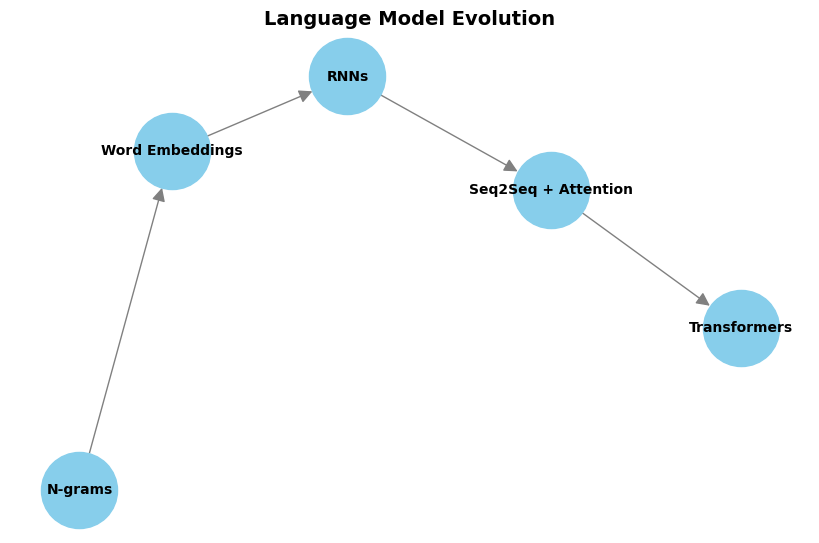

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

stages = [
    "N-grams",
    "Word Embeddings",
    "RNNs",
    "Seq2Seq + Attention",
    "Transformers"
]

G = nx.DiGraph()
G.add_edges_from([
    ("N-grams", "Word Embeddings"),
    ("Word Embeddings", "RNNs"),
    ("RNNs", "Seq2Seq + Attention"),
    ("Seq2Seq + Attention", "Transformers")
])

plt.figure(figsize=(8,5))
pos = nx.spring_layout(G, seed=42)  # layout for nodes
nx.draw(G, pos, with_labels=True, node_size=3000,
        node_color="skyblue", font_size=10, font_weight="bold",
        arrowsize=20, edge_color="gray")
plt.title("Language Model Evolution", fontsize=14, weight="bold")
plt.show()
